# Prédiction du churn client à partir du dataset Telco Customer
Ce dataset regroupe des informations relatives à des clients d’un opérateur télécom aux États-Unis.

Il comprend notamment :

- Des données démographiques

- Des informations sur les services et plans de souscription

- Des données de facturation

- Le statut de churn (résiliation)
  
## Objectif du projet
Modéliser et prédire la probabilité qu’un client résilie son contrat d’abonnement (churn).

La variable cible (target) correspond au statut de résiliation du client :

- Yes → le client a quitté l’opérateur

- No → le client est resté


In [98]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import GridSearchCV

from sklearn.preprocessing import OneHotEncoder

from sklearn.model_selection import GridSearchCV, StratifiedKFold, StratifiedKFold

from sklearn.neighbors import KNeighborsClassifier

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler


import seaborn as sns
import matplotlib.pyplot as plt


In [99]:
# 1. CHARGEMENT DES DONNÉES
print("=== CHARGEMENT DES DONNÉES ===")


# Download latest version
path="input/Telco_customer_churn.xlsx"
df = pd.read_excel(path)

print(df.head(5))

=== CHARGEMENT DES DONNÉES ===
   CustomerID  Count        Country       State         City  Zip Code  \
0  3668-QPYBK      1  United States  California  Los Angeles     90003   
1  9237-HQITU      1  United States  California  Los Angeles     90005   
2  9305-CDSKC      1  United States  California  Los Angeles     90006   
3  7892-POOKP      1  United States  California  Los Angeles     90010   
4  0280-XJGEX      1  United States  California  Los Angeles     90015   

                 Lat Long   Latitude   Longitude  Gender  ...        Contract  \
0  33.964131, -118.272783  33.964131 -118.272783    Male  ...  Month-to-month   
1   34.059281, -118.30742  34.059281 -118.307420  Female  ...  Month-to-month   
2  34.048013, -118.293953  34.048013 -118.293953  Female  ...  Month-to-month   
3  34.062125, -118.315709  34.062125 -118.315709  Female  ...  Month-to-month   
4  34.039224, -118.266293  34.039224 -118.266293    Male  ...  Month-to-month   

  Paperless Billing             Payme

In [100]:
# 2. EXPLORATION RAPIDE
print("\n=== EXPLORATION DES DONNÉES ===")

# Afficher la forme du dataset et les colonnes
print("\n")
print(f"Forme du dataset: {df.shape}")
print("\n")
print(f"Colonnes: {list(df.columns)}")

# Explorer les types de données et les valeurs manquantes
print("\n")
print("\nTypes de données et valeurs manquantes:")
print(df.info())

# Afficher les statistiques descriptives
print("\n")
print("Valeurs manquantes:")
print(df.isnull().sum())



=== EXPLORATION DES DONNÉES ===


Forme du dataset: (7043, 33)


Colonnes: ['CustomerID', 'Count', 'Country', 'State', 'City', 'Zip Code', 'Lat Long', 'Latitude', 'Longitude', 'Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Tenure Months', 'Phone Service', 'Multiple Lines', 'Internet Service', 'Online Security', 'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method', 'Monthly Charges', 'Total Charges', 'Churn Label', 'Churn Value', 'Churn Score', 'CLTV', 'Churn Reason']



Types de données et valeurs manquantes:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   obj


=== ANALYSE EXPLORATOIRE (EDA) ===
Statistiques descriptives:
        Count      Zip Code     Latitude    Longitude  Tenure Months  \
count  7043.0   7043.000000  7043.000000  7043.000000    7043.000000   
mean      1.0  93521.964646    36.282441  -119.798880      32.371149   
std       0.0   1865.794555     2.455723     2.157889      24.559481   
min       1.0  90001.000000    32.555828  -124.301372       0.000000   
25%       1.0  92102.000000    34.030915  -121.815412       9.000000   
50%       1.0  93552.000000    36.391777  -119.730885      29.000000   
75%       1.0  95351.000000    38.224869  -118.043237      55.000000   
max       1.0  96161.000000    41.962127  -114.192901      72.000000   

       Monthly Charges  Churn Value  Churn Score         CLTV  
count      7043.000000  7043.000000  7043.000000  7043.000000  
mean         64.761692     0.265370    58.699418  4400.295755  
std          30.090047     0.441561    21.525131  1183.057152  
min          18.250000     0.000

Text(0.5, 1.0, 'Distribution de la Survie')

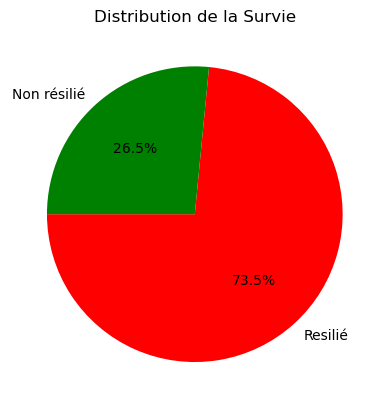

In [101]:
# 2.1 EDA - ANALYSE EXPLORATOIRE DÉTAILLÉE
print("\n=== ANALYSE EXPLORATOIRE (EDA) ===")

# Statistiques descriptives
print("Statistiques descriptives:")
print(df.describe())

print(df['Churn Label'].value_counts())


# 1. Distribution de la variable cible
plt.subplot()
churn_counts = df['Churn Label'].value_counts()
plt.pie(churn_counts.values, labels=['Resilié', 'Non résilié'], autopct='%1.1f%%', 
        colors=['red', 'green'], startangle=180)
plt.title('Distribution de la Survie')





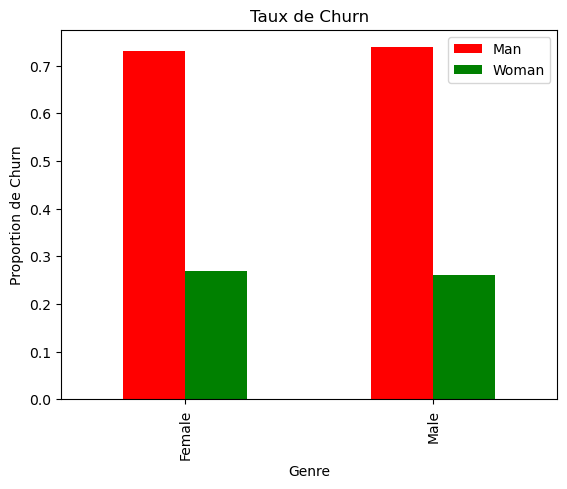

In [102]:



# 2. Churn par gender
plt.subplot()
churn_by_gender = pd.crosstab(df['Gender'], df['Churn Label'], normalize='index')
churn_by_gender.plot(kind='bar', color=['red', 'green'], ax=plt.gca())
plt.title('Taux de Churn')
plt.xlabel('Genre')
plt.ylabel('Proportion de Churn')
plt.legend(['Man', 'Woman'])




Text(0.5, 1.0, 'Distribution de la Variable Senior Citizen')

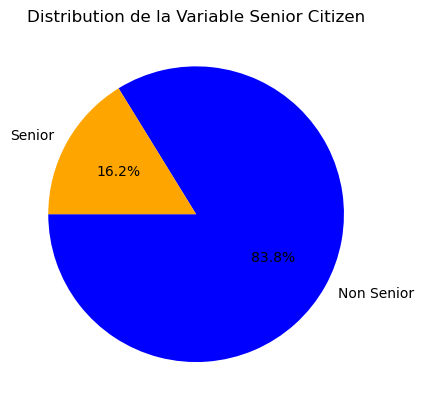

In [103]:
# 3. Distribution de la variable  senior citizen
plt.subplot()
churn_counts = df['Senior Citizen'].value_counts()
plt.pie(churn_counts.values, labels=['Non Senior', 'Senior'], autopct='%1.1f%%', 
        colors=['blue', 'orange'], startangle=180)
plt.title('Distribution de la Variable Senior Citizen')




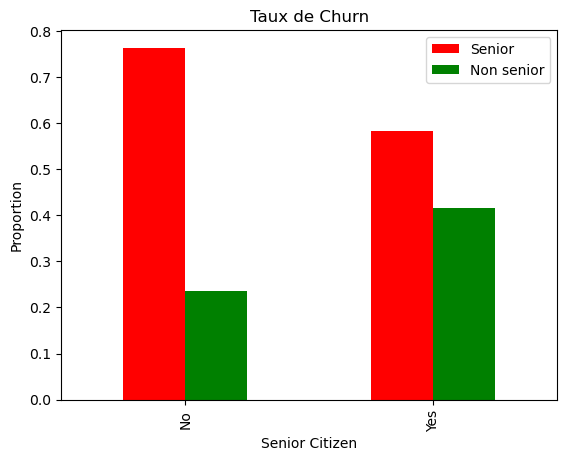

In [104]:
# 2. Churn par senior citizen
plt.subplot()
churn_by_gender = pd.crosstab(df['Senior Citizen'], df['Churn Label'], normalize='index')
churn_by_gender.plot(kind='bar', color=['red', 'green'], ax=plt.gca())
plt.title('Taux de Churn')
plt.xlabel('Senior Citizen')
plt.ylabel('Proportion')
plt.legend(['Senior', 'Non senior'])

    Latitude   Longitude  Tenure Months  Monthly Charges  CLTV
0  33.964131 -118.272783              2            53.85  3239
1  34.059281 -118.307420              2            70.70  2701
2  34.048013 -118.293953              8            99.65  5372
3  34.062125 -118.315709             28           104.80  5003
4  34.039224 -118.266293             49           103.70  5340


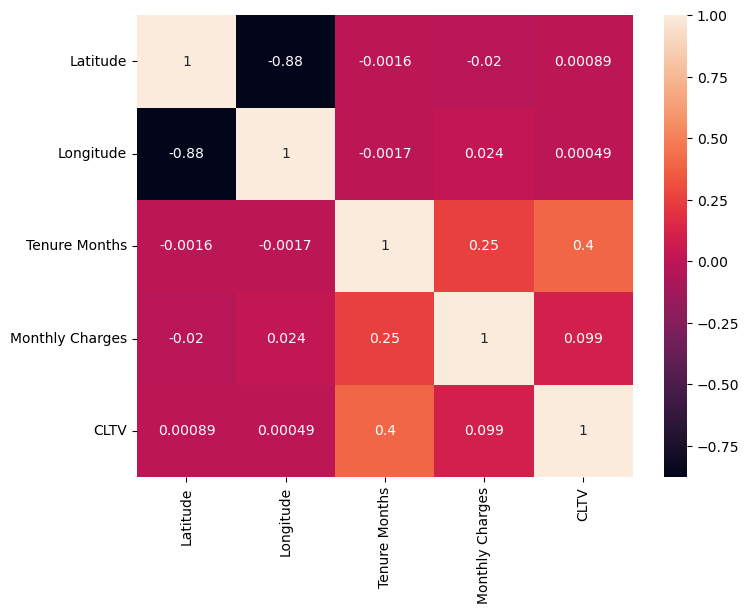

In [105]:
df_numeric = df.select_dtypes(include=np.number).drop(columns=['Zip Code','Churn Value','Churn Score','Count'])
print(df_numeric.head())
corr_df = df_numeric.corr(method="pearson")

plt.figure(figsize=(8, 6))
sns.heatmap(corr_df, annot=True)
plt.show()

## il ya une correlation entre tenure et CLTV et une correlation inversé entre longitude et latitude. si modele lineaire 
# on peut garder soit la longitude soit la latitude et supprimer l'autre. 

Text(0, 0.5, 'Tenure (mois)')

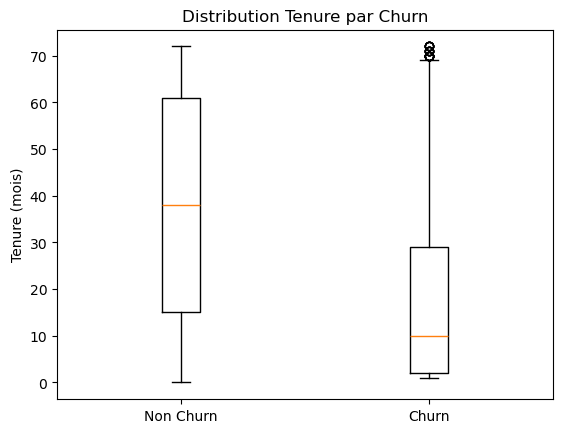

In [106]:
# 5. Churn par Tenure (boxplot)
plt.subplot()
churn_tenure = df[df['Churn Label'] == 'Yes']['Tenure Months'].dropna()
not_churn_tenure = df[df['Churn Label'] == 'No']['Tenure Months'].dropna()
plt.boxplot([not_churn_tenure, churn_tenure], tick_labels=['Non Churn', 'Churn'])
plt.title('Distribution Tenure par Churn')
plt.ylabel('Tenure (mois)')

## Les personnes qui ont churné ont tendance à avoir une tenure plus courte que celles qui n'ont pas churné, 
# ce qui suggère que les clients qui restent plus longtemps sont moins susceptibles de résilier
# On a quelques outliers plutot dans le groupe des churnés, ce qui peut indiquer que certains clients résilient même après une longue période de fidélité.

Text(0, 0.5, 'Nombre de clients')

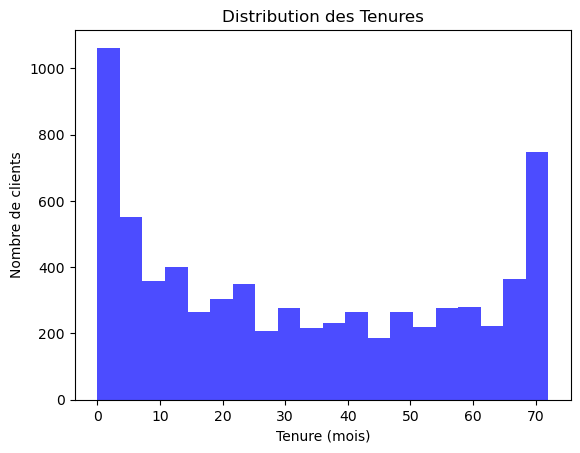

In [107]:
# Distribution des Tenures
plt.subplot()
plt.hist(df['Tenure Months'], bins=20, color='blue', alpha=0.7)
plt.title('Distribution des Tenures')
plt.xlabel('Tenure (mois)')
plt.ylabel('Nombre de clients')

/tmp/ipykernel_114266/1974951107.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='Churn Label', y='Tenure Months', data=df, palette=['green', 'red'])


Text(0, 0.5, 'Tenure (mois)')

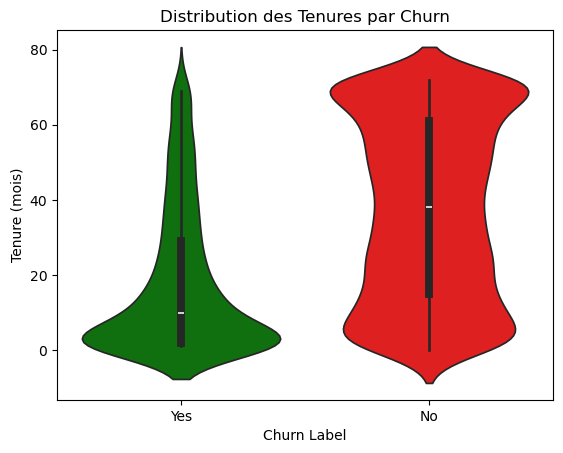

In [108]:
#Diagramme de disstribution des Tenures (violin plot  )
plt.subplot()
sns.violinplot(x='Churn Label', y='Tenure Months', data=df, palette=['green', 'red'])
plt.title('Distribution des Tenures par Churn')
plt.xlabel('Churn Label')
plt.ylabel('Tenure (mois)')

Text(0, 0.5, 'Monthly Charges')

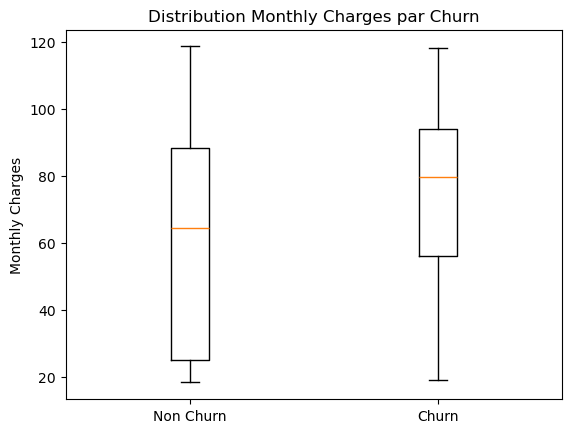

In [109]:
# 5. Churn par monthly charges (boxplot)
plt.subplot()
churn_tenure = df[df['Churn Label'] == 'Yes']['Monthly Charges'].dropna()
not_churn_tenure = df[df['Churn Label'] == 'No']['Monthly Charges'].dropna()
plt.boxplot([not_churn_tenure, churn_tenure], tick_labels=['Non Churn', 'Churn'])
plt.title('Distribution Monthly Charges par Churn')
plt.ylabel('Monthly Charges')

/tmp/ipykernel_114266/1667431421.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='Churn Label', y='Monthly Charges', data=df, palette=['green', 'red'])


Text(0, 0.5, 'Monthly Charges')

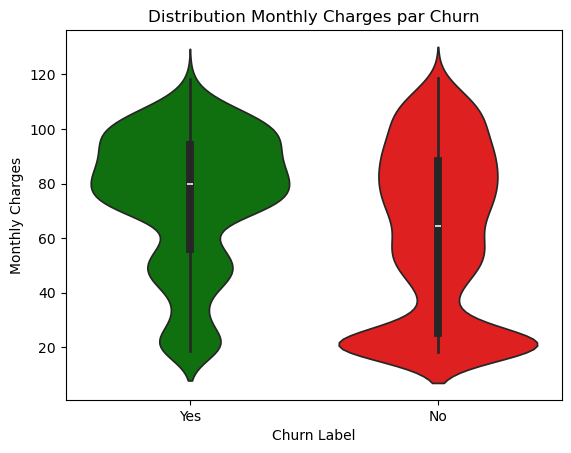

In [110]:
# 5. Churn par monthly charges (violon plot)
plt.subplot()
churn_tenure = df[df['Churn Label'] == 'Yes']['Monthly Charges'].dropna()
not_churn_tenure = df[df['Churn Label'] == 'No']['Monthly Charges'].dropna()
sns.violinplot(x='Churn Label', y='Monthly Charges', data=df, palette=['green', 'red'])
plt.title('Distribution Monthly Charges par Churn')
plt.xlabel('Churn Label')
plt.ylabel('Monthly Charges')

Text(0, 0.5, 'CLTV')

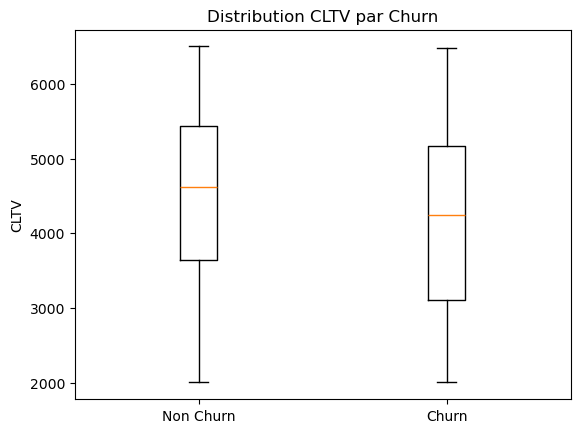

In [111]:
# 5. Churn par monthly CLTV (boxplot)
plt.subplot()
churn_tenure = df[df['Churn Label'] == 'Yes']['CLTV'].dropna()
not_churn_tenure = df[df['Churn Label'] == 'No']['CLTV'].dropna()
plt.boxplot([not_churn_tenure, churn_tenure], tick_labels=['Non Churn', 'Churn'])
plt.title('Distribution CLTV par Churn')
plt.ylabel('CLTV')

/tmp/ipykernel_114266/4244581210.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='Churn Label', y='CLTV', data=df, palette=['green', 'red'])


Text(0, 0.5, 'CLTV')

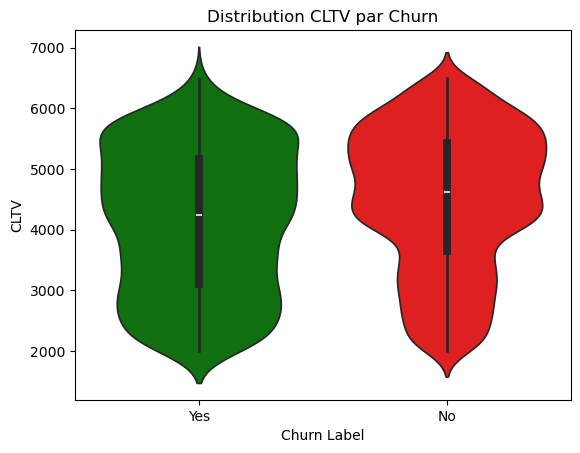

In [112]:
# 5. Churn parCLTV (violon plot)
plt.subplot()
churn_tenure = df[df['Churn Label'] == 'Yes']['CLTV'].dropna()
not_churn_tenure = df[df['Churn Label'] == 'No']['CLTV'].dropna()
sns.violinplot(x='Churn Label', y='CLTV', data=df, palette=['green', 'red'])
plt.title('Distribution CLTV par Churn')
plt.xlabel('Churn Label')
plt.ylabel('CLTV')

## EDA variables cateforielles

In [113]:
total_categorial = df.select_dtypes(include=['object']).drop(columns=['CustomerID','Churn Label','Churn Reason', 'State'])
df_categorial = df.select_dtypes(include=['object']).drop(columns=['CustomerID','Churn Label','Country','State','Churn Reason', 'City'])

#print(df_categorial.columns)
#print(df_categorial.head())

print(df['City'].nunique())
print(df['Partner'].nunique())
print(df['Dependents'].nunique())
print(df['Phone Service'].nunique())
print(df['Multiple Lines'].nunique())
print(df['Internet Service'].nunique())
print(df['Online Security'].nunique())
print(df['Online Backup'].nunique())
print(df['Device Protection'].nunique())
print(df['Tech Support'].nunique())
print(df['Streaming TV'].nunique())
print(df['Streaming Movies'].nunique())
print(df['Contract'].nunique())
print(df['Paperless Billing'].nunique())
print(df['Payment Method'].nunique())

1129
2
2
2
3
3
3
3
3
3
3
3
3
2
4


Partner
No     0.329580
Yes    0.196649
Name: Churn Value, dtype: float64


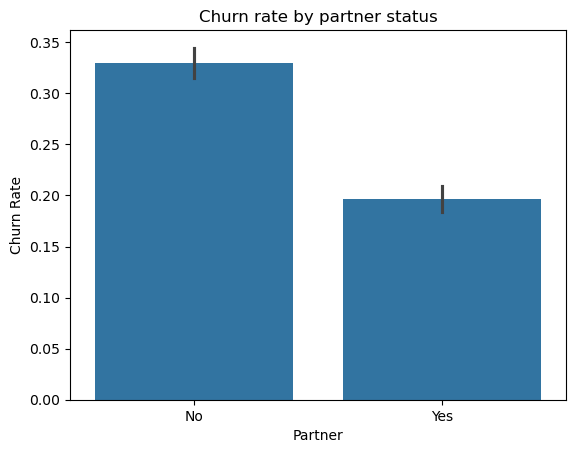

In [114]:
# Bar plot pour la variable Partner

churn_rate =df.groupby("Partner")["Churn Value"].mean()
print(churn_rate)

import seaborn as sns
sns.barplot(data=df,
            x="Partner",
            y="Churn Value")

plt.title("Churn rate by partner status")
plt.ylabel("Churn Rate")
plt.xlabel("Partner")
plt.show()

## Les clients qui ont un partenaire ont un taux de churn plus bas que ceux qui n'en ont pas, 
# ce qui suggère que les clients avec un partenaire sont plus susceptibles de rester fidèles à l'entreprise.

Dependents
No     0.325517
Yes    0.065151
Name: Churn Value, dtype: float64


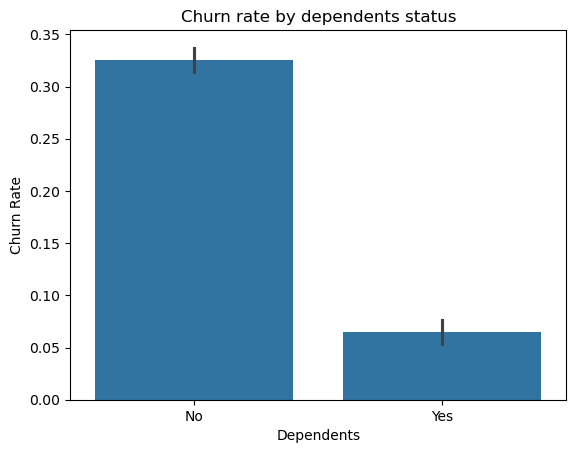

In [115]:
# Bar plot pour la variable Dependents

churn_rate =df.groupby("Dependents")["Churn Value"].mean()
print(churn_rate)

import seaborn as sns
sns.barplot(data=df,
            x="Dependents",
            y="Churn Value")

plt.title("Churn rate by dependents status")
plt.ylabel("Churn Rate")
plt.xlabel("Dependents")
plt.show()

## Les clients qui ont un partenaire ont un taux de churn plus bas que ceux qui n'en ont pas, 
# ce qui suggère que les clients avec un partenaire sont plus susceptibles de rester fidèles à l'entreprise.

Phone Service
No     0.249267
Yes    0.267096
Name: Churn Value, dtype: float64


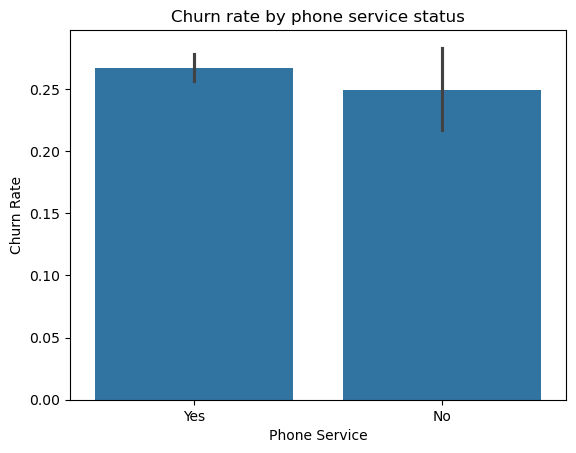

In [116]:
# Bar plot pour la variable Phone Service

churn_rate =df.groupby("Phone Service")["Churn Value"].mean()
print(churn_rate)

import seaborn as sns
sns.barplot(data=df,
            x="Phone Service",
            y="Churn Value")

plt.title("Churn rate by phone service status")
plt.ylabel("Churn Rate")
plt.xlabel("Phone Service")
plt.show()

Phone Service
No     0.249267
Yes    0.267096
Name: Churn Value, dtype: float64


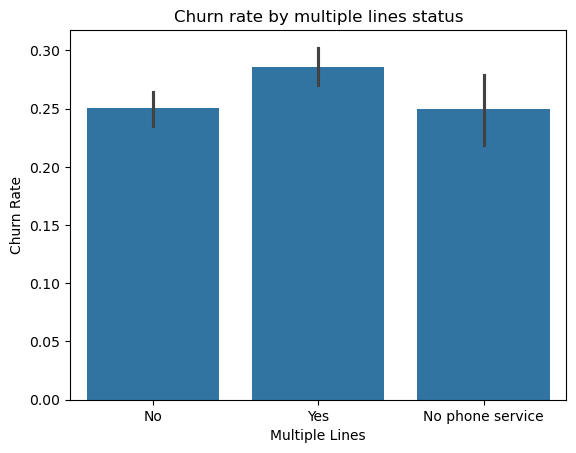

In [117]:
# Bar plot pour la variable Multiple Lines

churn_rate =df.groupby("Phone Service")["Churn Value"].mean()
print(churn_rate)

import seaborn as sns
sns.barplot(data=df,
            x="Multiple Lines",
            y="Churn Value")

plt.title("Churn rate by multiple lines status")
plt.ylabel("Churn Rate")
plt.xlabel("Multiple Lines")
plt.show()

## Ceux qui ont plusieurs lignes ont un taux de churn plus haut que ceux qui n'en ont pas ou qui n'ont pas de service téléphonique, 
# ce qui suggère que les clients avec plusieurs lignes sont plus susceptibles de résilier leur contrat.

Internet Service
DSL            0.189591
Fiber optic    0.418928
No             0.074050
Name: Churn Value, dtype: float64


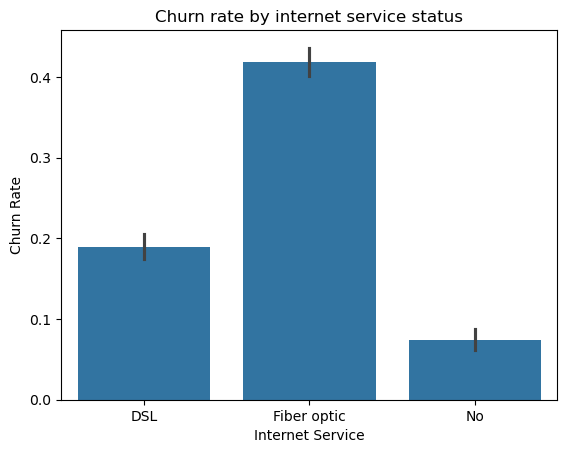

In [118]:
# Bar plot pour la variable Internet Service'

churn_rate =df.groupby("Internet Service")["Churn Value"].mean()
print(churn_rate)

import seaborn as sns
sns.barplot(data=df,
            x="Internet Service",
            y="Churn Value")

plt.title("Churn rate by internet service status")
plt.ylabel("Churn Rate")
plt.xlabel("Internet Service")
plt.show()

## Ceux qui ont la fibre optique ont un taux de churn plus haut que ceux qui ont la DSL ou pas de service internet, 
# ce qui suggère que les clients avec la fibre optique sont plus susceptibles de résilier leur contrat.

Online Security
No                     0.417667
No internet service    0.074050
Yes                    0.146112
Name: Churn Value, dtype: float64


Text(0.5, 0, 'Online Security')

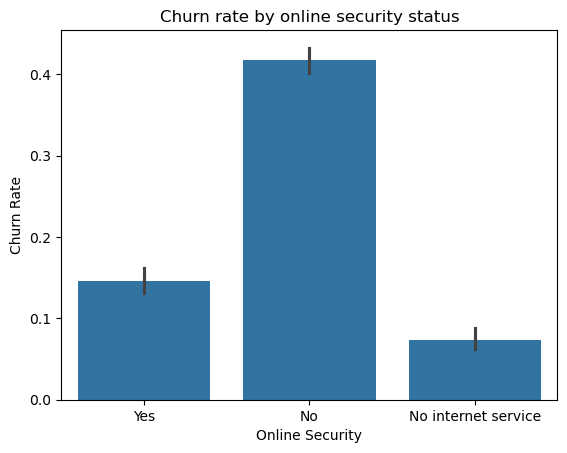

In [119]:
# Online Security
# Bar plot pour la variable Online Security

churn_rate =df.groupby("Online Security")["Churn Value"].mean()
print(churn_rate)

import seaborn as sns
sns.barplot(data=df,
            x="Online Security",
            y="Churn Value")

plt.title("Churn rate by online security status")
plt.ylabel("Churn Rate")
plt.xlabel("Online Security")

# Les client qui n'ont pas de sécurité en ligne ont un taux de churn plus haut que ceux qui en ont, 
# ce qui suggère que les clients sans sécurité en ligne sont plus susceptibles de résilier leur

Online Backup
No                     0.399288
No internet service    0.074050
Yes                    0.215315
Name: Churn Value, dtype: float64


Text(0.5, 0, 'Online Backup')

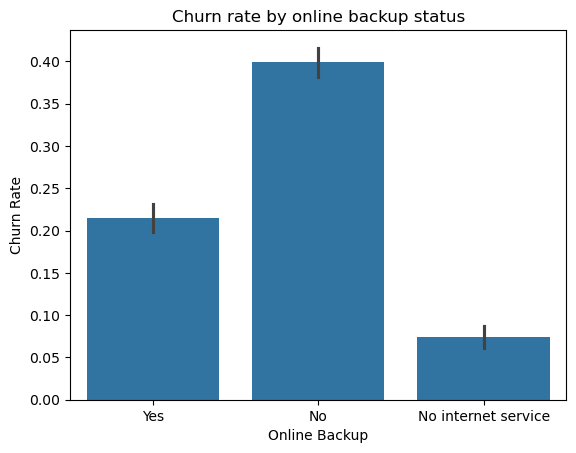

In [120]:
# Online Backup
# Bar plot pour la variable Online Backup
churn_rate =df.groupby("Online Backup")["Churn Value"].mean()
print(churn_rate)
import seaborn as sns
sns.barplot(data=df,  
            x="Online Backup",
            y="Churn Value")
plt.title("Churn rate by online backup status")
plt.ylabel("Churn Rate")
plt.xlabel("Online Backup")

# Les client qui n'ont pas de backup en ligne ont un taux de churn plus haut que ceux qui en ont, 
# ce qui suggère que les clients sans backup en ligne sont plus susceptibles de résilier leur contrat.

Device Protection
No                     0.391276
No internet service    0.074050
Yes                    0.225021
Name: Churn Value, dtype: float64


Text(0.5, 0, 'Device Protection')

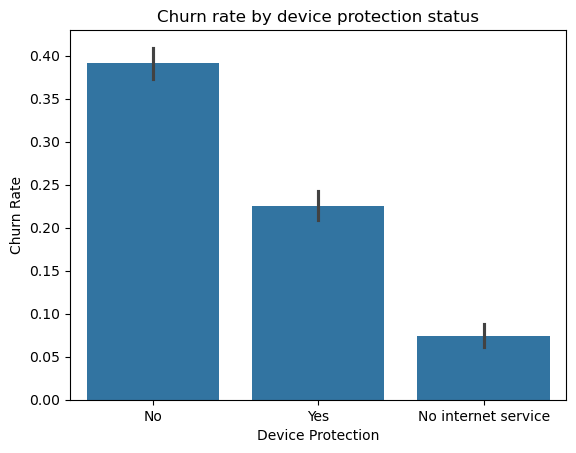

In [121]:
# Device Protection
# Bar plot pour la variable Device Protection
churn_rate =df.groupby("Device Protection")["Churn Value"].mean()
print(churn_rate)
import seaborn as sns
sns.barplot(data=df,
            x="Device Protection",
            y="Churn Value")
plt.title("Churn rate by device protection status")
plt.ylabel("Churn Rate")
plt.xlabel("Device Protection")


# Les client qui n'ont pas de protection de l'appareil ont un taux de churn plus haut que ceux qui en ont, 
# ce qui suggère que les clients sans protection de l'appareil sont plus susceptibles de résilier leur contrat.

Tech Support
No                     0.416355
No internet service    0.074050
Yes                    0.151663
Name: Churn Value, dtype: float64


Text(0.5, 0, 'Tech Support')

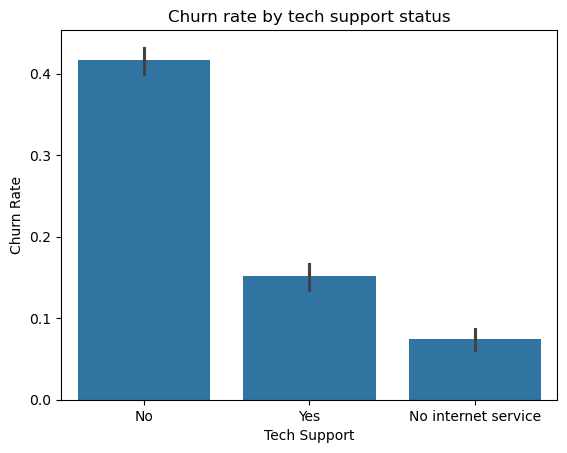

In [122]:
# Tech Support
# Bar plot pour la variable Tech Support
churn_rate =df.groupby("Tech Support")["Churn Value"].mean()
print(churn_rate)
import seaborn as sns
sns.barplot(data=df,
            x="Tech Support",
            y="Churn Value")
plt.title("Churn rate by tech support status")
plt.ylabel("Churn Rate")
plt.xlabel("Tech Support")

# Les client qui n'ont pas de support technique ont un taux de churn plus haut que ceux qui en ont, 
# ce qui suggère que les clients sans support technique sont plus susceptibles de résilier leur contrat

Streaming TV
No                     0.335231
No internet service    0.074050
Yes                    0.300702
Name: Churn Value, dtype: float64


Text(0.5, 0, 'Streaming TV')

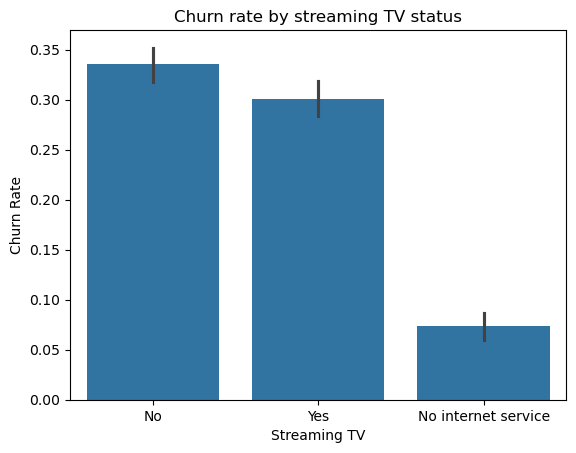

In [123]:
#Streaming TV'
# Bar plot pour la variable Streaming TV
churn_rate =df.groupby("Streaming TV")["Churn Value"].mean()
print(churn_rate)
import seaborn as sns
sns.barplot(data=df,    
            x="Streaming TV",
            y="Churn Value")
plt.title("Churn rate by streaming TV status")
plt.ylabel("Churn Rate")
plt.xlabel("Streaming TV")

# Le sreaming TV n'a pas d'impact significatif sur le taux de churn,
# ce qui suggère que les clients avec ou sans streaming TV sont à peu près aussi susceptibles

Streaming Movies
No                     0.336804
No internet service    0.074050
Yes                    0.299414
Name: Churn Value, dtype: float64


Text(0.5, 0, 'Streaming Movies')

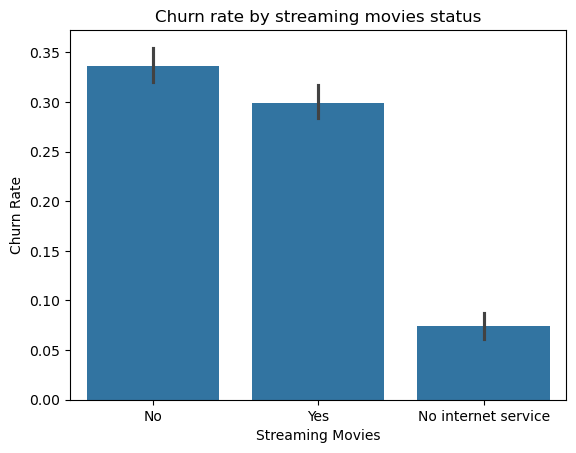

In [124]:
# Streaming Movies'
# Bar plot pour la variable Streaming Movies
churn_rate =df.groupby("Streaming Movies")["Churn Value"].mean()
print(churn_rate)
import seaborn as sns
sns.barplot(data=df,    
            x="Streaming Movies",
            y="Churn Value")    
plt.title("Churn rate by streaming movies status")
plt.ylabel("Churn Rate")
plt.xlabel("Streaming Movies")

# Le sreaming Movies n'a pas d'impact significatif sur le taux de churn,
# ce qui suggère que les clients avec ou sans streaming Movies sont à peu près aussi susceptibles de résilier leur contrat.

Contract
Month-to-month    0.427097
One year          0.112695
Two year          0.028319
Name: Churn Value, dtype: float64


Text(0.5, 0, 'Contract')

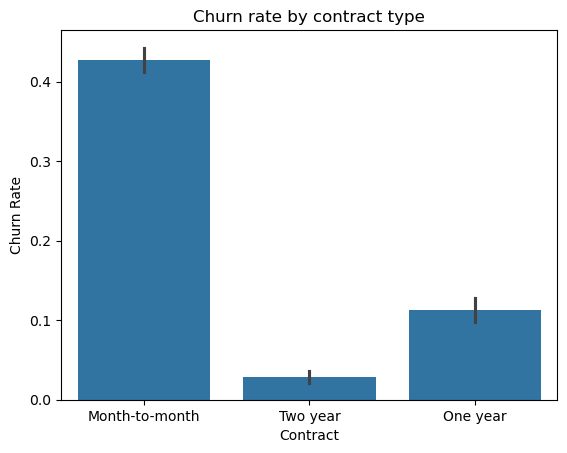

In [125]:
# Contract
# Bar plot pour la variable Contract
churn_rate =df.groupby("Contract")["Churn Value"].mean()
print(churn_rate)
import seaborn as sns
sns.barplot(data=df,    
            x="Contract",
            y="Churn Value")
plt.title("Churn rate by contract type")
plt.ylabel("Churn Rate")
plt.xlabel("Contract")  

# Les clients avec un contrat mensuel ont un taux de churn plus haut que ceux avec un contrat annuel ou de deux ans,
# ce qui suggère que les clients avec un contrat mensuel sont plus susceptibles de résilier 
# leur contrat que ceux avec des contrats plus longs.

Paperless Billing
No     0.163301
Yes    0.335651
Name: Churn Value, dtype: float64


Text(0.5, 0, 'Paperless Billing')

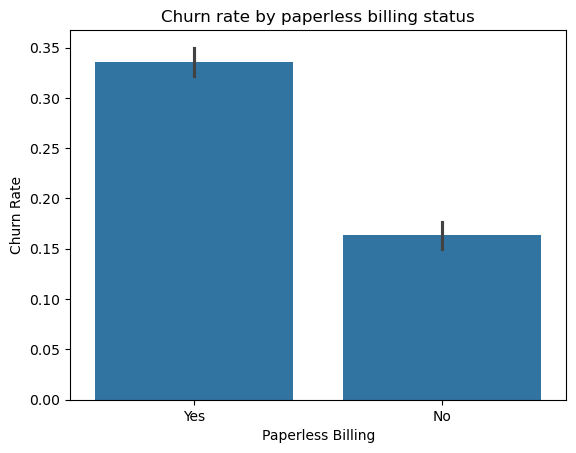

In [126]:
# Paperless Billing
# Bar plot pour la variable Paperless Billing
churn_rate =df.groupby("Paperless Billing")["Churn Value"].mean()
print(churn_rate)
import seaborn as sns
sns.barplot(data=df,    
            x="Paperless Billing",
            y="Churn Value")
plt.title("Churn rate by paperless billing status")
plt.ylabel("Churn Rate")
plt.xlabel("Paperless Billing")

# Les clients avec une facturation sans papier ont un taux de churn plus haut que ceux avec une facturation papier,
# ce qui suggère que les clients avec une facturation sans papier sont plus susceptibles de résilier leur contrat que ceux avec une facturation papier.

['Mailed check' 'Electronic check' 'Bank transfer (automatic)'
 'Credit card (automatic)']
Payment Method
Bank transfer (automatic)    0.167098
Credit card (automatic)      0.152431
Electronic check             0.452854
Mailed check                 0.191067
Name: Churn Value, dtype: float64


Text(0.5, 0, 'Payment Method')

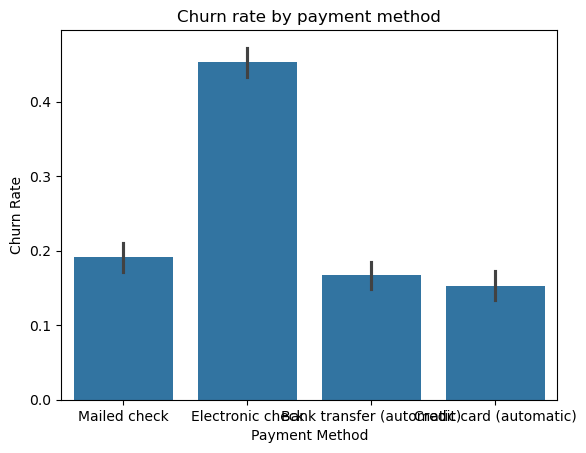

In [127]:
#Payment Method
# Bar plot pour la variable Payment Method
print(df['Payment Method'].unique())
churn_rate =df.groupby("Payment Method")["Churn Value"].mean()
print(churn_rate)
import seaborn as sns
sns.barplot(data=df,    
            x="Payment Method",
            y="Churn Value")
plt.title("Churn rate by payment method")
plt.ylabel("Churn Rate")
plt.xlabel("Payment Method")

# Les clients qui paient par Electronic check  ont un taux de churn plus haut que les autres modes de paiement, 
# notamment ceux qui paient par chèque ou par virement bancaire,

In [128]:
# Fonction de calcul du WoE et de l'IV pour la variable

import pandas as pd
import numpy as np

def calculate_woe_iv(df, feature, target):

    grouped = df.groupby(feature)[target].agg(['count','sum'])

    grouped['non_event'] = grouped['count'] - grouped['sum']

    dist_event = grouped['sum'] / grouped['sum'].sum()
    dist_non_event = grouped['non_event'] / grouped['non_event'].sum()

    woe = np.log(dist_non_event / dist_event)

    iv = ((dist_non_event - dist_event) * woe).sum()

    return woe, iv

In [129]:
for feature in total_categorial.columns:
    woe, iv = calculate_woe_iv(df, feature, 'Churn Value')
    print(f"Feature: {feature}, IV: {iv} " )

# Les features que l'on ne va pas inclure dans les features sont: 
# Gender, Phone Service, Multiple Lines,.

Feature: Country, IV: 0.0 
Feature: City, IV: inf 
Feature: Lat Long, IV: inf 
Feature: Gender, IV: 0.000380436636119779 
Feature: Senior Citizen, IV: 0.1056211828540469 
Feature: Partner, IV: 0.1187285028426526 
Feature: Dependents, IV: 0.4591246268145649 
Feature: Phone Service, IV: 0.0007448404939444331 
Feature: Multiple Lines, IV: 0.008206811545041692 
Feature: Internet Service, IV: 0.6179525742200359 
Feature: Online Security, IV: 0.7177771388702754 
Feature: Online Backup, IV: 0.5286341230339946 
Feature: Device Protection, IV: 0.4997245050043479 
Feature: Tech Support, IV: 0.699567294911045 
Feature: Streaming TV, IV: 0.38046232986293527 
Feature: Streaming Movies, IV: 0.38137431200674277 
Feature: Contract, IV: 1.238559792784284 
Feature: Paperless Billing, IV: 0.20306838467477684 
Feature: Payment Method, IV: 0.4571089328419982 
Feature: Total Charges, IV: inf 


/home/djamali/anaconda3/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
/home/djamali/anaconda3/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
/home/djamali/anaconda3/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [130]:
# Choix des features à inclure dans le modèle:
features_to_include = ['Partner', 'Dependents', 'Internet Service', 'Online Security', 'Online Backup', 'Device Protection', 'Tech Support', 'Contract', 'Paperless Billing', 'Payment Method', 'Tenure Months', 'Monthly Charges', 'CLTV']
print(df.keys())

X = df.drop(columns=['Count','CustomerID','Churn Value', 'Churn Score','Churn Label','Churn Reason', 'State','Country','City','Gender','Phone Service','Multiple Lines','Total Charges'])
y = df['Churn Value']


print(X.columns)

Index(['CustomerID', 'Count', 'Country', 'State', 'City', 'Zip Code',
       'Lat Long', 'Latitude', 'Longitude', 'Gender', 'Senior Citizen',
       'Partner', 'Dependents', 'Tenure Months', 'Phone Service',
       'Multiple Lines', 'Internet Service', 'Online Security',
       'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV',
       'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method',
       'Monthly Charges', 'Total Charges', 'Churn Label', 'Churn Value',
       'Churn Score', 'CLTV', 'Churn Reason'],
      dtype='object')
Index(['Zip Code', 'Lat Long', 'Latitude', 'Longitude', 'Senior Citizen',
       'Partner', 'Dependents', 'Tenure Months', 'Internet Service',
       'Online Security', 'Online Backup', 'Device Protection', 'Tech Support',
       'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing',
       'Payment Method', 'Monthly Charges', 'CLTV'],
      dtype='object')


In [131]:
# Split test train
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

## Preprocessing des variables numériques & categorielles



In [132]:
df_numeric = df.select_dtypes(include=['int64','float64']).drop(columns=['Zip Code','Churn Value','Churn Score','Count'])
col_numeric = df_numeric.columns.tolist()
print(col_numeric)


df_categorial = df.select_dtypes(include=['object']).drop(columns=['Gender' , 'Multiple Lines' , 'Phone Service' , 'CustomerID','Churn Label','Country','State','Churn Reason', 'City', 'Total Charges'])
col_categorial = df_categorial.columns.tolist()
print(col_categorial)

num_features = X_train.select_dtypes(include=['int64','float64']).columns
cat_features = X_train.select_dtypes(include=['object']).columns
#print("Features numériques:", num_features)
#print("Features catégorielles:", cat_features)  


['Latitude', 'Longitude', 'Tenure Months', 'Monthly Charges', 'CLTV']
['Lat Long', 'Senior Citizen', 'Partner', 'Dependents', 'Internet Service', 'Online Security', 'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method']


In [133]:
#Valeurs numériques



num_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

In [134]:
# Variables categorielles


cat_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])


In [135]:
#combiner les pipelines

preprocessor = ColumnTransformer([
    ("num", num_pipeline, num_features),
    ("cat", cat_pipeline, cat_features)
])

In [136]:
# Model de base : KNN
model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", KNeighborsClassifier(n_neighbors=5))
])

In [137]:
# entrainement du modèle & prediction
model.fit(X_train, y_train)

# prediction
y_pred = model.predict(X_test)

In [138]:
# Evaluation du modèle KNN
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)  
scores = cross_val_score(
    model,
    X_train,
    y_train,
    cv=5,
    scoring="roc_auc"
)
print(f"Accuracy: {accuracy}")
print("Classification Report:")
print(report)
print("Confusion Matrix:")
print(conf_matrix)  
print(f"Cross-validation AUC scores: {scores}")
print(f"Mean AUC: {scores.mean()}")

Accuracy: 0.7622427253371186
Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.84      0.84      1035
           1       0.55      0.54      0.55       374

    accuracy                           0.76      1409
   macro avg       0.69      0.69      0.69      1409
weighted avg       0.76      0.76      0.76      1409

Confusion Matrix:
[[873 162]
 [173 201]]
Cross-validation AUC scores: [0.80682387 0.80385706 0.80916259 0.78736691 0.77718756]
Mean AUC: 0.7968795979198098


In [139]:
# Model Regression Logistique
from sklearn.linear_model import LogisticRegression
model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(penalty=None))
])

# entrainement du modèle & prediction
model.fit(X_train, y_train)

# prediction
y_pred = model.predict(X_test)

/home/djamali/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [140]:
#Evaluaion du modèle de regression logistique
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)  
scores = cross_val_score(
    model,
    X_train,
    y_train,
    cv=5,
    scoring="roc_auc"
)
print(f"Accuracy: {accuracy}")
print("Classification Report:")
print(report)
print("Confusion Matrix:")
print(conf_matrix)  
print(f"Cross-validation AUC scores: {scores}")
print(f"Mean AUC: {scores.mean()}")

/home/djamali/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/home/djamali/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-

Accuracy: 0.7381121362668559
Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.83      0.82      1035
           1       0.51      0.48      0.49       374

    accuracy                           0.74      1409
   macro avg       0.66      0.66      0.66      1409
weighted avg       0.73      0.74      0.74      1409

Confusion Matrix:
[[860 175]
 [194 180]]
Cross-validation AUC scores: [0.7791188  0.74884074 0.75525504 0.76811998 0.75085836]
Mean AUC: 0.7604385848565622


/home/djamali/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [141]:
# Model Random Forest
from sklearn.ensemble import RandomForestClassifier



model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(n_estimators=100))
])

# entrainement du modèle & prediction
model.fit(X_train, y_train)

# prediction
y_pred = model.predict(X_test)

In [142]:
#Evaluaion du modèle randome forest
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)  
scores = cross_val_score(
    model,
    X_train,
    y_train,
    cv=5,
    scoring="roc_auc"
)
print(f"Accuracy: {accuracy}")
print("Classification Report:")
print(report)
print("Confusion Matrix:")
print(conf_matrix)  
print(f"Cross-validation AUC scores: {scores}")
print(f"Mean AUC: {scores.mean()}")

Accuracy: 0.78708303761533
Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1035
           1       0.63      0.49      0.55       374

    accuracy                           0.79      1409
   macro avg       0.73      0.69      0.71      1409
weighted avg       0.78      0.79      0.78      1409

Confusion Matrix:
[[926 109]
 [191 183]]
Cross-validation AUC scores: [0.85587223 0.84553382 0.85316191 0.83628399 0.82837795]
Mean AUC: 0.8438459801641913


In [143]:
# Model Boosting
from sklearn.ensemble import GradientBoostingClassifier



model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", GradientBoostingClassifier(random_state=42))
])

# entrainement du modèle & prediction
model.fit(X_train, y_train)

# prediction
y_pred = model.predict(X_test)

In [144]:
#Evaluaion du modèle Gradient boosting
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)  
scores = cross_val_score(
    model,
    X_train,
    y_train,
    cv=5,
    scoring="roc_auc"
)
print(f"Accuracy: {accuracy}")
print("Classification Report:")
print(report)
print("Confusion Matrix:")
print(conf_matrix)  
print(f"Cross-validation AUC scores: {scores}")
print(f"Mean AUC: {scores.mean()}")

Accuracy: 0.8026969481902059
Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.90      0.87      1035
           1       0.66      0.52      0.58       374

    accuracy                           0.80      1409
   macro avg       0.75      0.71      0.73      1409
weighted avg       0.79      0.80      0.79      1409

Confusion Matrix:
[[936  99]
 [179 195]]
Cross-validation AUC scores: [0.87388921 0.86894722 0.86878565 0.85278222 0.83662187]
Mean AUC: 0.8602052331762401


In [148]:
param_grid = {
    'classifier__n_estimators': [100, 200],
    'classifier__learning_rate': [0.05, 0.1],
    'classifier__max_depth': [3, 5],
    'classifier__subsample': [0.8, 1.0],
    'classifier__min_samples_leaf': [1, 2]
}



# Grille de recherche
grid_search = GridSearchCV(estimator=model, param_grid=param_grid, 
                           scoring='roc_auc', cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42), n_jobs=-1, verbose=1)


grid_search.fit(X_train, y_train)

print(f"Best parameters: {grid_search.best_params_}")
print(f"Best cross-validation score: {grid_search.best_score_}")


Fitting 5 folds for each of 32 candidates, totalling 160 fits


Best parameters: {'classifier__learning_rate': 0.05, 'classifier__max_depth': 5, 'classifier__min_samples_leaf': 2, 'classifier__n_estimators': 100, 'classifier__subsample': 0.8}
Best cross-validation score: 0.8648257594810375
